In [1]:
# 구글 드라이브 연결

import google

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

# 엑셀 파일 경로
dataset_path = '/content/drive/MyDrive/2nd project/data/dataset.csv'

try:
    # .csv 파일이므로 read_csv를 사용합니다.
    df = pd.read_csv(dataset_path)
    print(f'Successfully loaded dataset from: {dataset_path}')
    display(df.head())
except FileNotFoundError:
    print(f'Error: 파일을 찾을 수 없습니다: {dataset_path}')
except Exception as e:
    print(f'An error occurred: {e}')

Successfully loaded dataset from: /content/drive/MyDrive/2nd project/data/dataset.csv


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


### 1. 결측치(Missing Values) 확인

데이터셋에 결측치가 있는지 확인합니다. `df.info()`는 각 컬럼의 Non-Null 개수를 보여주며, `df.isnull().sum()`은 각 컬럼별 결측치의 총 개수를 나타냅니다. 마지막으로 `df.isnull().sum() / len(df) * 100`를 통해 결측치의 비율을 확인할 수 있습니다.

In [4]:
# 데이터프레임의 기본 정보 및 Non-Null 개수 확인
print("데이터프레임 정보:")
df.info()

데이터프레임 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberO

In [6]:
# 각 컬럼별 결측치 개수 확인
print("\n컬럼별 결측치 개수:")
missing_values = df.isnull().sum().sort_values(ascending=False)
display(missing_values[missing_values > 0])


컬럼별 결측치 개수:


,0
DaySinceLastOrder,307
OrderAmountHikeFromlastYear,265
Tenure,264
OrderCount,258
CouponUsed,256
HourSpendOnApp,255
WarehouseToHome,251


In [7]:
# 각 컬럼별 결측치 비율 확인
print("\n컬럼별 결측치 비율 (%):")
missing_percentage = (df.isnull().sum() / len(df) * 100)
display(missing_percentage[missing_percentage > 0].sort_values(ascending=False))


컬럼별 결측치 비율 (%):


,0
DaySinceLastOrder,5.452931
OrderAmountHikeFromlastYear,4.706927
Tenure,4.689165
OrderCount,4.582593
CouponUsed,4.547069
HourSpendOnApp,4.529307
WarehouseToHome,4.458259


In [8]:
# 숫자형 컬럼의 기술 통계량 확인
print("숫자형 컬럼 기술 통계량:")
display(df.describe())

숫자형 컬럼 기술 통계량:


,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.221492
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.193869
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,146.000000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.000000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.000000
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,325.000000


In [9]:
df['HourSpendOnApp'].mode()

,HourSpendOnApp
0,3.0


### 숫자형 컬럼 간의 상관관계 히트맵 시각화

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49707 (\N{HANGUL SYLLABLE SUS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

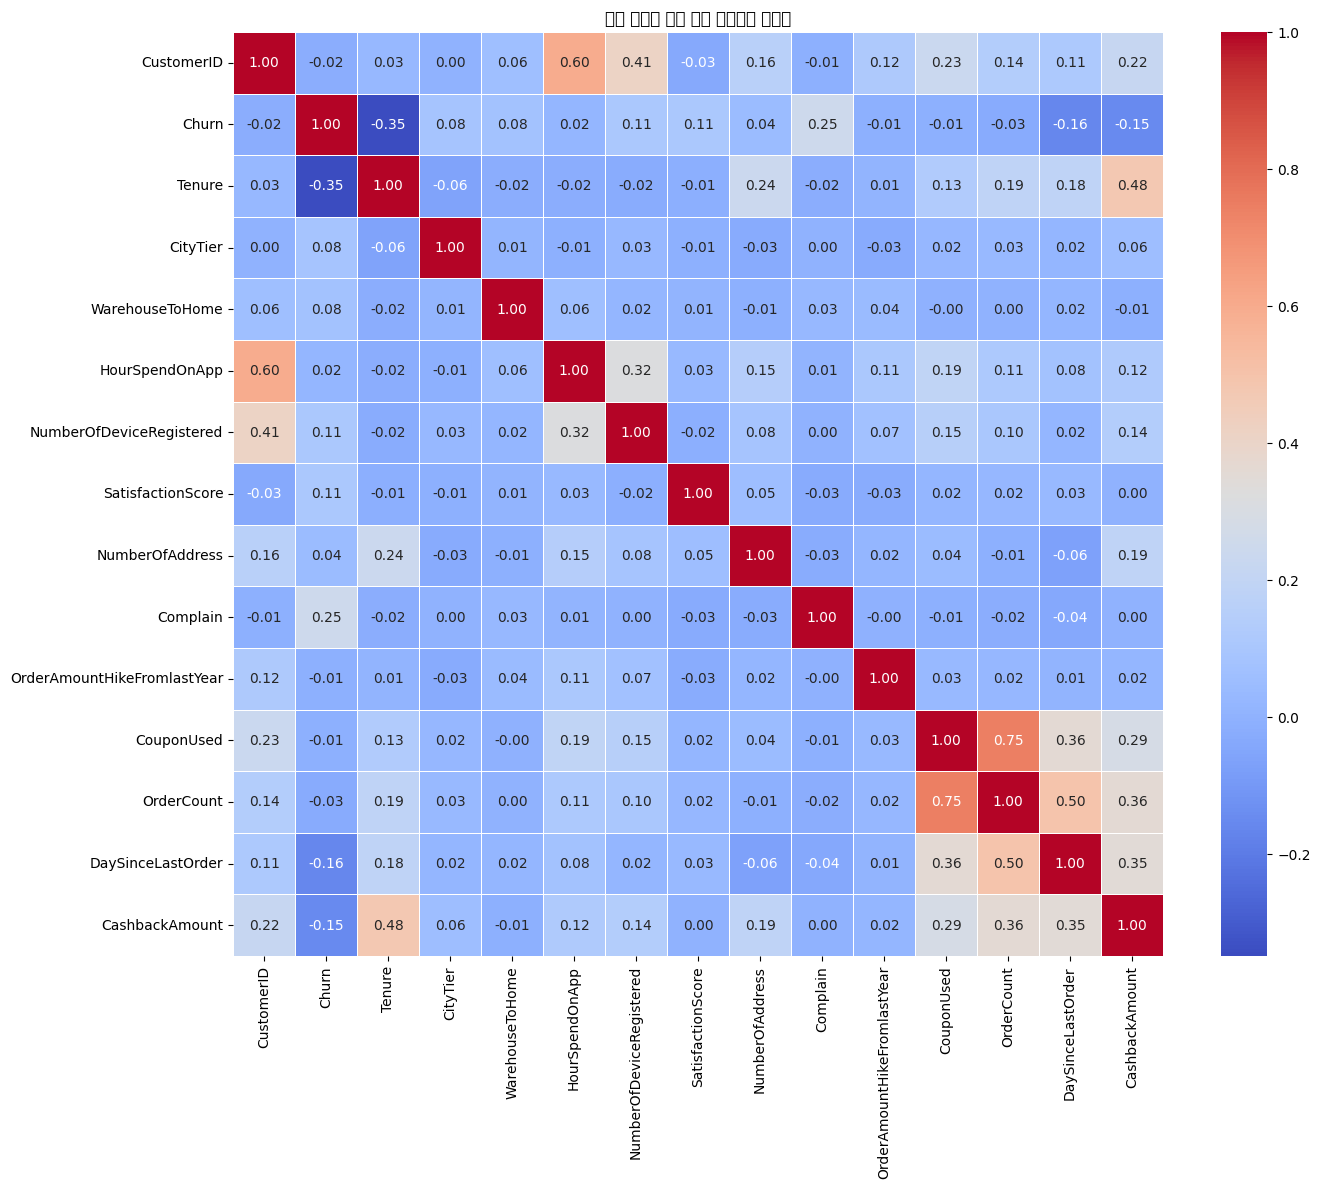

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 숫자형 컬럼만 선택하여 상관관계 행렬 계산
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('전체 숫자형 컬럼 간의 상관관계 히트맵')
plt.show()

### 'HourSpendOnApp' 컬럼 결측치 최빈값으로 대체

In [11]:
def fill_hour_spend_on_app(df):
    """
    'HourSpendOnApp' 컬럼의 결측치를 최빈값으로 대체합니다.

    Parameters:
    df (pd.DataFrame): 처리할 데이터프레임.

    Returns:
    pd.DataFrame: 'HourSpendOnApp' 컬럼의 결측치가 처리된 데이터프레임.
    """
    # 'HourSpendOnApp' 컬럼의 최빈값 계산
    # mode()는 Series를 반환할 수 있으므로 [0]을 사용하여 첫 번째 최빈값을 선택합니다.
    hour_spend_on_app_mode = df['HourSpendOnApp'].mode()[0]

    # 결측치(NaN)를 최빈값으로 대체
    df['HourSpendOnApp'].fillna(hour_spend_on_app_mode, inplace=False)

    print(f"'HourSpendOnApp' 컬럼의 최빈값: {hour_spend_on_app_mode}")
    print(f"'HourSpendOnApp' 컬럼의 결측치 처리 후 남은 결측치 수: {df['HourSpendOnApp'].isnull().sum()}")

    return df

In [13]:
# 함수 사용

# 이미 앞선 실행에서 처리되었으므로, 이 코드를 다시 실행해도 추가적인 결측치는 없을 것입니다.
# 만약 원본 데이터를 다시 로드하여 테스트하고 싶다면, `df = pd.read_csv(dataset_path)`를 먼저 실행하세요.
df = fill_hour_spend_on_app(df.copy())

# 처리된 데이터프레임의 head를 확인
df.head()

'HourSpendOnApp' 컬럼의 최빈값: 3.0
'HourSpendOnApp' 컬럼의 결측치 처리 후 남은 결측치 수: 255


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


### 'WarehouseToHome' 컬럼 결측치 'CityTier'별 중앙값으로 대체

In [16]:
def fill_warehouse_to_home(df):
    """
    'WarehouseToHome' 컬럼의 결측치를 'CityTier'별 중앙값으로 대체합니다.

    Parameters:
    df (pd.DataFrame): 처리할 데이터프레임.

    Returns:
    pd.DataFrame: 'WarehouseToHome' 컬럼의 결측치가 처리된 데이터프레임.
    """
    # 'CityTier'별 'WarehouseToHome'의 중앙값 계산
    WarehouseToHome_by_citytier_median = df.groupby('CityTier')['WarehouseToHome'].median()

    print("'CityTier'별 'WarehouseToHome' 중앙값:")
    print(WarehouseToHome_by_citytier_median)

    # 'CityTier'별 중앙값을 사용하여 'WarehouseToHome' 결측치 대체
    for tier, median_val in WarehouseToHome_by_citytier_median.items():
        df.loc[(df['CityTier'] == tier) & (df['WarehouseToHome'].isnull()), 'WarehouseToHome'] = median_val

    print("\n'WarehouseToHome' 컬럼의 결측치 처리 후:")
    print(df['WarehouseToHome'].isnull().sum()) # 결측치가 모두 채워졌는지 확인

    return df

In [17]:
# 함수 사용
df = fill_warehouse_to_home(df.copy())

'CityTier'별 'WarehouseToHome' 중앙값:
CityTier
1    13.0
2    13.0
3    14.0
Name: WarehouseToHome, dtype: float64

'WarehouseToHome' 컬럼의 결측치 처리 후:
0


### 'CouponUsed' 컬럼 결측치 'CashbackAmount / OrderCount' 비율 기반 4분위 중앙값으로 대체
- `CouponUsed` 와 `OrderCount`의 상관관계 높음

In [19]:
def fill_coupon_used(df):
    """
    'CouponUsed' 컬럼의 결측치를 'CashbackAmount / OrderCount' 비율 기반 4분위 중앙값으로 대체합니다.

    Parameters:
    df (pd.DataFrame): 처리할 데이터프레임.

    Returns:
    pd.DataFrame: 'CouponUsed' 컬럼의 결측치가 처리된 데이터프레임.
    """

    # 'CashbackAmount'와 'OrderCount'를 사용하여 'CashbackPerOrder' 비율 계산
    # 'OrderCount'가 0이거나 NaN인 경우를 처리하여 division by zero 또는 NaN 발생 방지
    # OrderCount의 최소값이 1이므로 0인 경우는 없으나, NaN은 존재할 수 있습니다.
    df['CashbackPerOrder'] = df['CashbackAmount'] / df['OrderCount']

    # 'CashbackPerOrder'의 4분위수를 기반으로 그룹 생성
    # qcut은 NaN 값을 자동으로 처리하지 않으므로, NaN이 아닌 값들로 분위수를 계산합니다.
    # 'duplicates='drop''은 중복된 분위 경계가 있을 경우 자동으로 처리합니다.
    # labels=False로 하면 0, 1, 2, 3의 정수 레이블이 할당됩니다.
    df['CashbackPerOrder_quantile'] = pd.qcut(
        df['CashbackPerOrder'],
        q=4,
        labels=False,
        duplicates='drop' # 중복된 분위 경계가 있을 경우 처리
    )

    # 각 분위 그룹별 'CouponUsed'의 중앙값 계산
    median_coupon_used_per_quantile = df.groupby('CashbackPerOrder_quantile')['CouponUsed'].median()

    # 결측치(NaN)를 각 그룹의 중앙값으로 대체
    # 먼저, 'CouponUsed'가 NaN이면서 'CashbackPerOrder_quantile'이 유효한 값인 경우를 처리합니다.
    for q_label, median_val in median_coupon_used_per_quantile.items():
        df.loc[
            (df['CashbackPerOrder_quantile'] == q_label) & (df['CouponUsed'].isnull()),
            'CouponUsed'
        ] = median_val

    # 'CashbackPerOrder' 또는 'OrderCount'가 NaN이어서 'CashbackPerOrder_quantile'도 NaN이 된 경우,
    # 즉 분위 그룹에 속하지 못한 'CouponUsed'의 잔여 결측치들을 전체 'CouponUsed'의 중앙값으로 대체합니다.
    overall_median_coupon_used = df['CouponUsed'].median()
    df['CouponUsed'].fillna(overall_median_coupon_used, inplace=True)

    print("'CouponUsed' 컬럼의 결측치 처리 후:")
    print(df['CouponUsed'].isnull().sum()) # 결측치가 모두 채워졌는지 확인

    # 임시로 생성했던 컬럼들 제거 (선택 사항)
    df.drop(columns=['CashbackPerOrder', 'CashbackPerOrder_quantile'], inplace=True)

    return df

In [20]:
# fill_coupon_used 함수를 사용하여 'CouponUsed' 컬럼의 결측치를 처리합니다.
df = fill_coupon_used(df.copy())

# 처리된 데이터프레임의 상위 5행을 확인합니다.
display(df.head())

'CouponUsed' 컬럼의 결측치 처리 후:
0


/tmp/ipykernel_7458/637149993.py:42: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CouponUsed'].fillna(overall_median_coupon_used, inplace=True)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


In [21]:
display(df.head(64))

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,50060,0,26.0,Phone,1,19.0,Credit Card,Female,2.0,2,Laptop & Accessory,5,Married,2,0,11.0,1.0,1.0,3.0,145
60,50061,0,6.0,Phone,1,20.0,CC,Female,NaN,3,Mobile,4,Divorced,2,0,13.0,0.0,1.0,6.0,128
61,50062,0,13.0,Mobile Phone,1,10.0,Credit Card,Female,2.0,3,Others,3,Divorced,2,0,14.0,3.0,9.0,9.0,290
62,50063,0,28.0,Mobile Phone,1,20.0,Credit Card,Male,3.0,2,Others,4,Single,9,0,11.0,1.0,2.0,15.0,287


### 2. 이상치(Outliers) 확인

In [ ]:
# 숫자형 컬럼의 기술 통계량 확인
print("숫자형 컬럼 기술 통계량:")
display(df.describe())

숫자형 컬럼 기술 통계량:


,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.221492
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.193869
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,146.000000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.000000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.000000
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,325.000000
